# Vertical Stratification & Brunt-Väisälä Frequency

Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

This notebook retrieves temperature and salinity profiles from the Argo array to explore vertical ocean stratification, mixed layer depth, and the Brunt-Väisälä frequency.

## Learning Goals

By the end of this activity, you will be able to:

1. **Query and visualize Argo profiles** — retrieve temperature and salinity profiles across a range of latitudes using the Argovis API.
2. **Estimate the mixed layer depth (MLD)** — identify the base of the surface mixed layer from temperature and potential density profiles and compare visual estimates to algorithmic ones.
3. **Compare MLD across latitudes** — describe how mixed layer depth varies from the Southern Ocean to the tropics and explain the physical drivers.
4. **Compute potential density, N², and oscillation period** — calculate the Brunt-Väisälä frequency and interpret vertical stratification strength.
5. **Compare stratification across ocean basins** — contrast N² profiles at similar latitudes in different basins and relate differences to temperature and salinity structure.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Register and copy the key provided.
3. Paste it below, replacing `'guest'`.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ──────────────────────────────
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import gsw
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.ticker as ticker
import cartopy.feature as cfeature

APIKEY  = 'guest'  # ← paste your key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API
- `plot_maps` — scatter profile locations on a map
- `compare_profiles` — plot individual or mean vertical profiles; to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`
- `_arr` — safely convert Profile.getvar() output to a plain float ndarray
- `compute_dT_MLD_surf` — compute ΔT between MLD and surface for student estimates

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions import traverse_query, plot_maps, compare_profiles, traverse_interpolate
from notebook_helpers.functions_MLD import plot_profiles_with_mld, compute_dT_MLD_surf, inspect_float_at_depths, n2_to_period, compute_derived_properties, build_mld_summary_table, plot_mld_vs_latitude
from notebook_helpers.functions_candidates_for_functions import _arr

## Activity 1 — Mixed Layer Depth vs. Latitude

In many regions of the ocean, the **mixed layer** is the layer at the top of the ocean where temperature is approximately constant with depth. The **mixed layer depth (MLD)** is the threshold below which water temperature begins to decline rapidly.

### Step 0 — Choose your floats

Choose either the **Pacific Ocean** or the **Atlantic Ocean** (not the Arctic, Indian, or
Southern Ocean). Identify **five Argo floats** within that basin at the following latitudes:

- one quite far to the **south** (south of 50°S)
- one in the **southern tropics or subtropics** (roughly 15–40°S)
- one **near the equator** (between 10°S and 10°N)
- one in the **northern tropics or subtropics** (roughly 15–40°N)
- one quite far to the **north** (north of 50°N)

Try to keep your floats along roughly the same longitude — you want to control for longitude,
not compare across ocean basins here.

To find floats: visit [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo), click on a float and read in the pop-up window its profile ID (e.g. `4902898_151`), latitude, and longitude

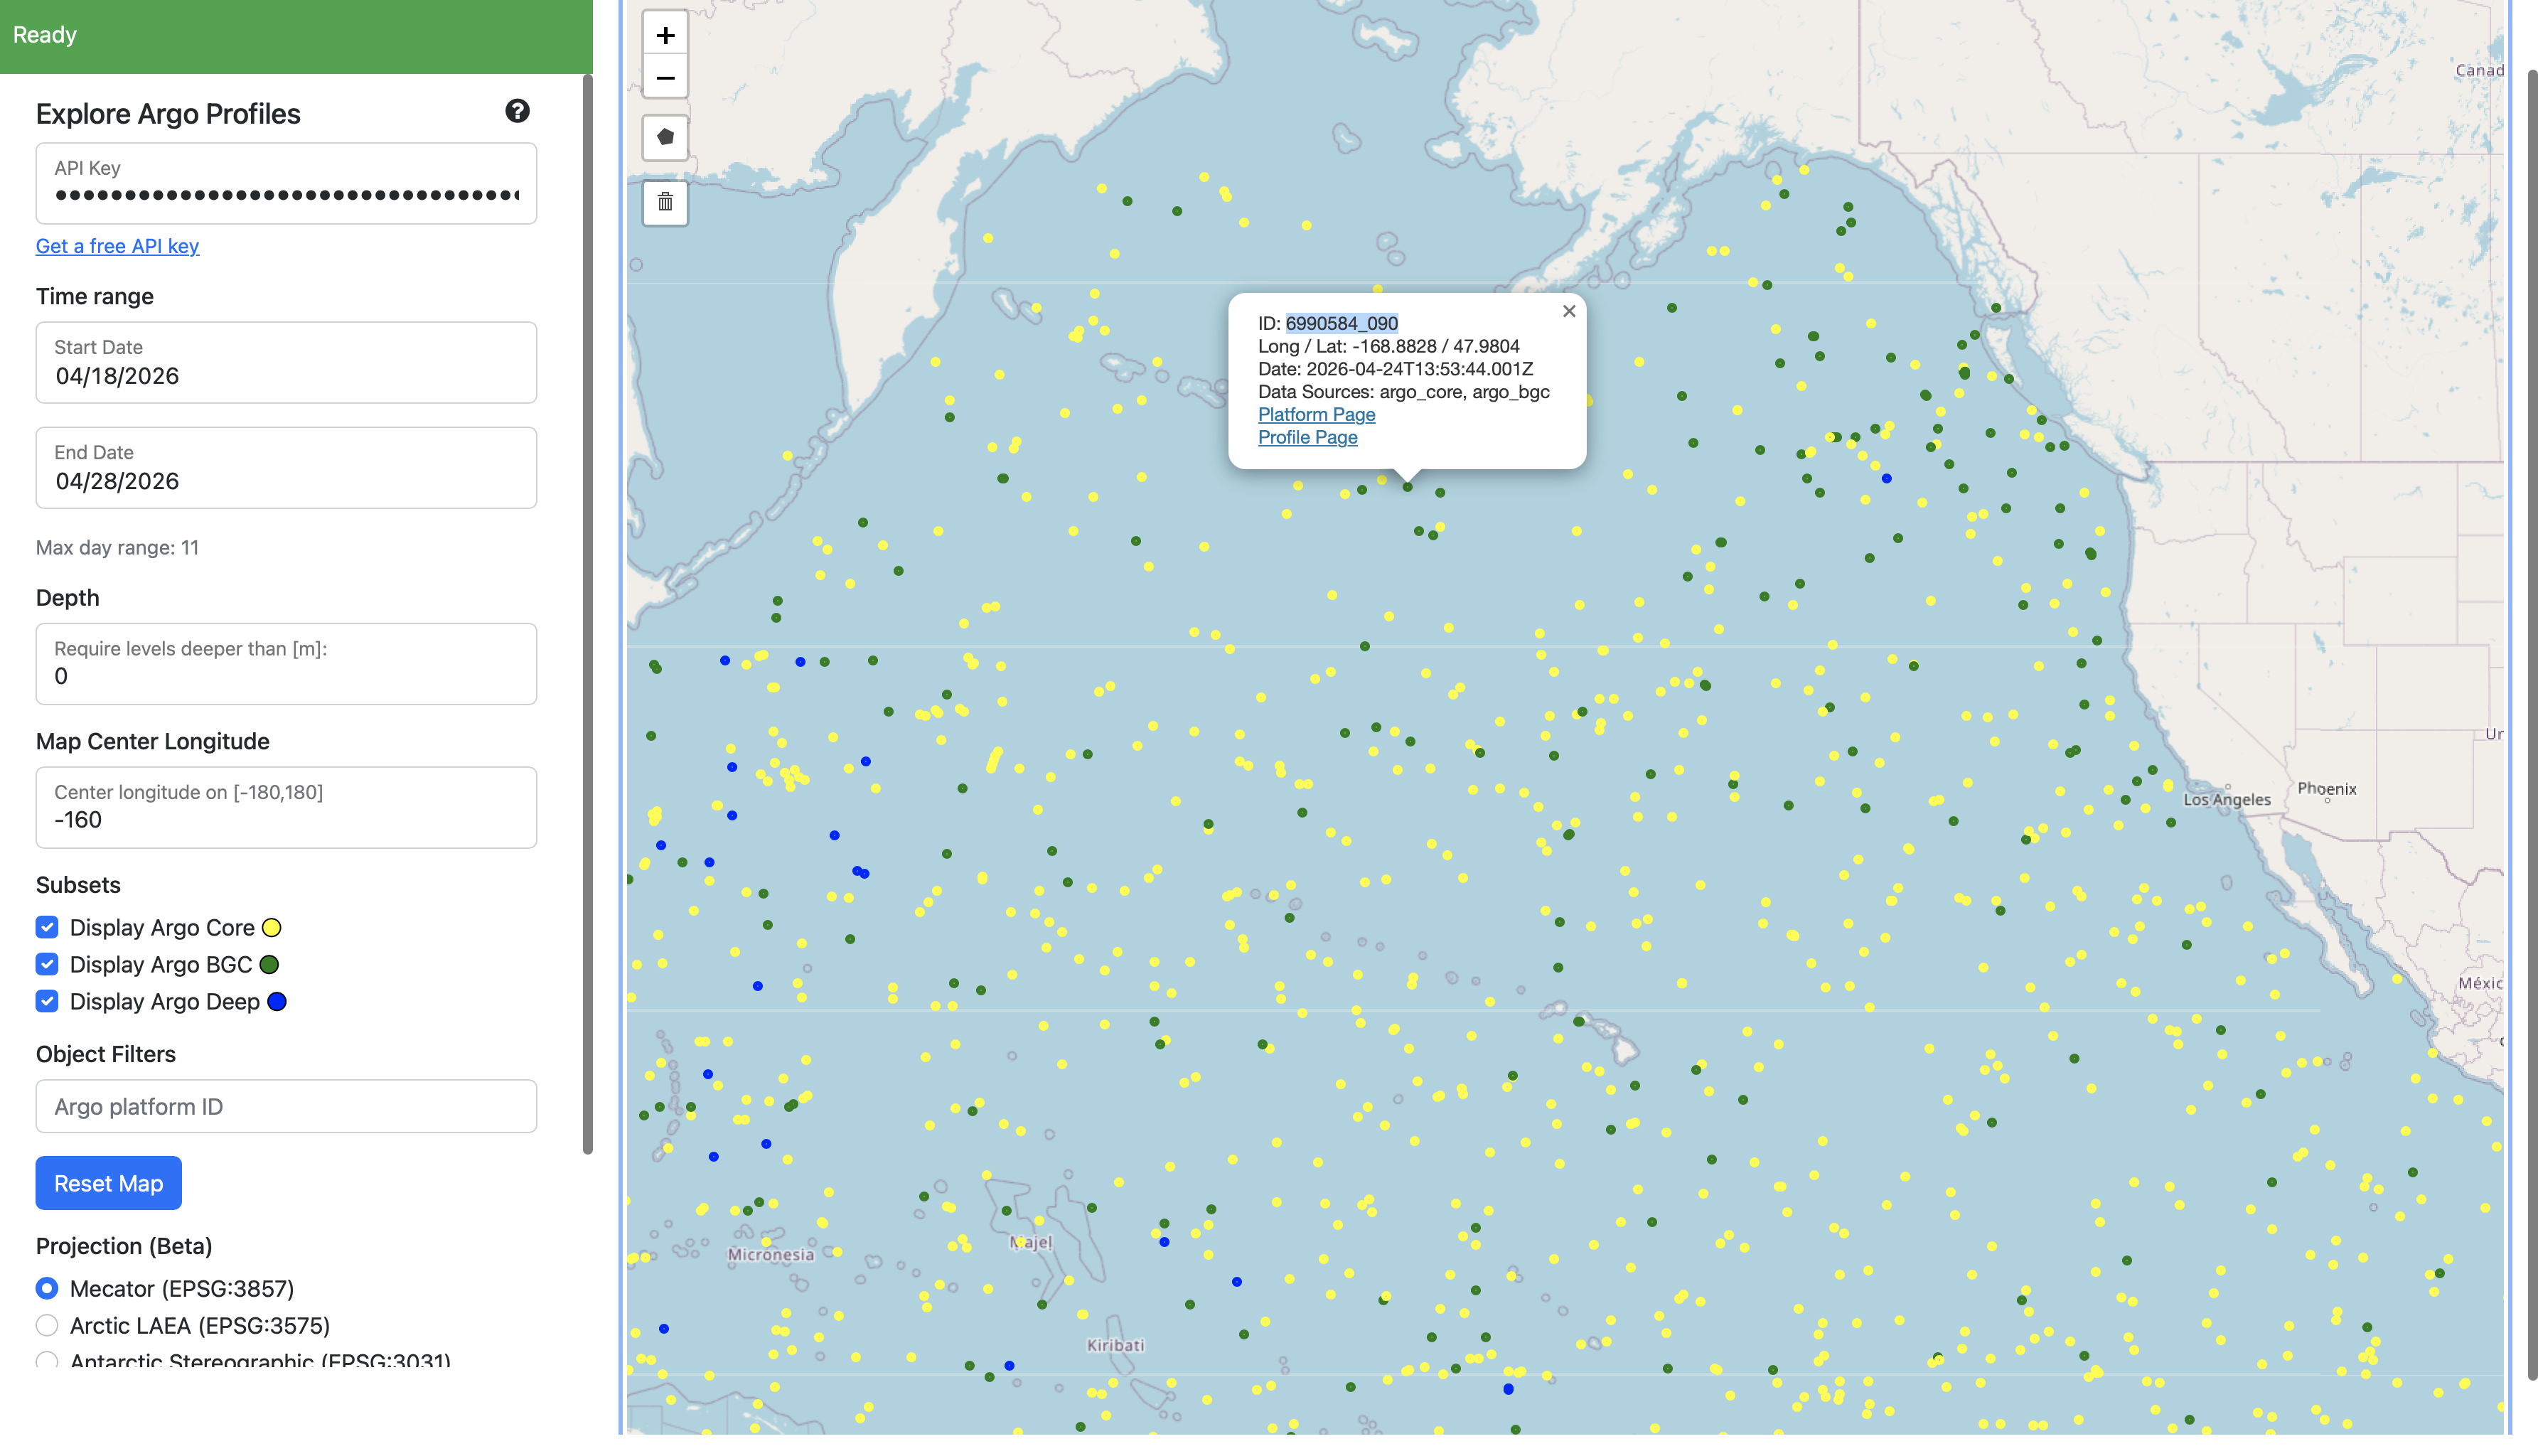

*Example of the Argovis interface - use this to identify your five float IDs.*

## Setup: configuration

✏️ **Student Work — Float Configuration**

Replace the example float IDs below with the five Argo float IDs you identified on Argovis. Make sure they span the target latitudes within your chosen ocean basin.

> **How to edit:** uncomment the `target_profiles` template block (select all commented lines, then press `Ctrl+/` or `Cmd+/`), and replace each `"ID#"` placeholder with a real profile ID.

In [3]:
# MODIFY HERE
argo_collections = {
    "argo": "temperature,salinity"
}

target_profiles = [
    {"id": "7902209_042"},
    {"id": "5905656_273"},
    {"id": "5905572_070"},
    {"id": "4903574_080"},
    {"id": "4902514_161"},
]

# Enter your five float IDs here:
# target_profiles = [
#     {"id": "ID1"},
#     {"id": "ID2"},
#     {"id": "ID3"},
#     {"id": "ID4"},
#     {"id": "ID5"},
# ]

time_periods = [
    {"startDate": "2026-01-01T00:00:00Z", "endDate": "2026-05-12T00:00:00Z"}
]

interpolation_levels = list(range(0, 2001, 5))
# interpolation_levels = avh.rg_levels()

salinity_key    = {'argo': 'salinity'}
temperature_key = {'argo': 'temperature'}

# Define 5 colors — one per float, shared between map and profiles
PROFILE_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

### Step 1 — Query Argo profiles from Argovis and interpolate them

In [4]:
# ── Step 1: Query Argo profiles — run, do not modify ─────────────────────────────
platform_results = traverse_query(target_profiles, time_periods, argo_collections,
                                  avh.queryProfile,
                                  apikey=APIKEY, apiroot=APIROOT)

In [5]:
# ── Step 2: Interpolate profiles — run, do not modify ───────────────────────────
platform_profiles = traverse_interpolate(platform_results, interpolation_levels)

### Step 2 — Visualize float locations

The map below shows where your five floats are located. Check that they span the expected 
range of latitudes and are roughly aligned in longitude.

<GeoAxes: title={'center': 'All profile locations'}>

/usr/local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


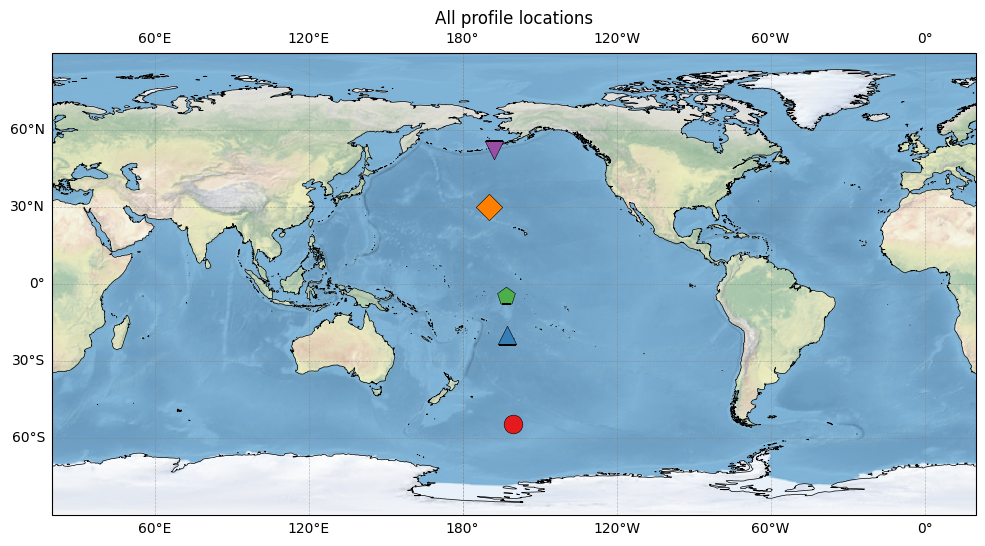

In [6]:
# ── Map of float locations — run, do not modify ─────────────────────────────────
all_lats, all_lons = [], []
for ds in platform_profiles:
    for region_list in platform_profiles[ds]:
        for time_list in region_list:
            all_lats.append([p.latitude  for p in time_list])
            all_lons.append([p.longitude for p in time_list])

plot_maps(all_lats, all_lons, title='All profile locations', colors=PROFILE_COLORS,
          margin=15, markersize=8, global_view=True, central_longitude=200,
          fig_settings={'figsize': (12, 6), 'show_plot': False})


### Step 3 — Inspect the temperature profiles
The plots below show the temperature profile for each float. The vertical axis is pressure
(dbar), which you can treat as equivalent to depth in meters.

Study each profile carefully. The mixed layer appears as the **near-vertical section at the
top** of the profile where temperature is roughly constant. Below it, temperature begins to
drop — that transition marks the bottom of the mixed layer.

> **Tip:** Adjust `max_depth` in the cell below to zoom in on the upper ocean and identify
> the MLD more precisely.

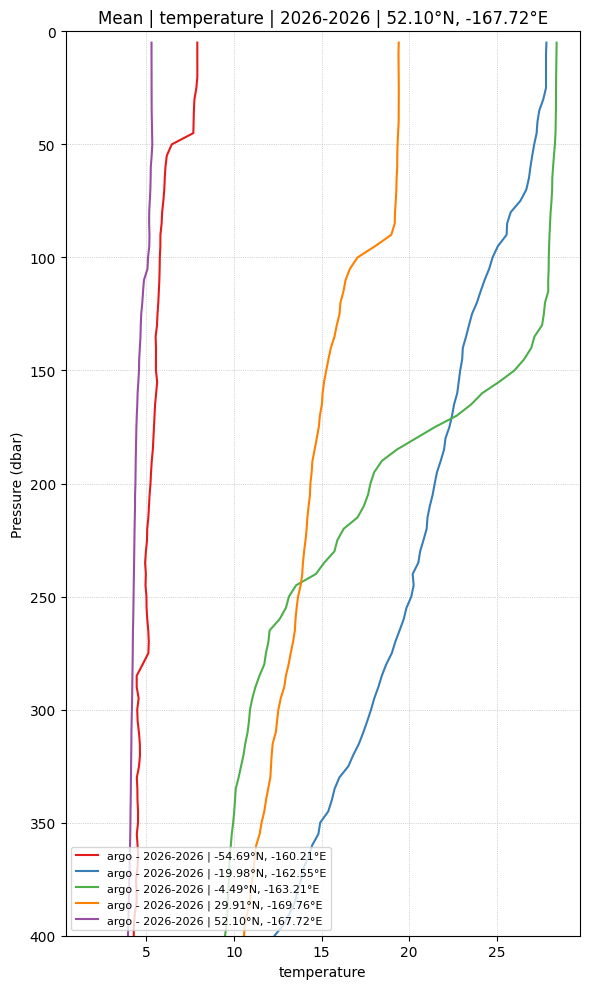

In [7]:
# ── Temperature profiles — run, do not modify ───────────────────────────────────
# Adjust max_depth to zoom in on the upper portion of each profile
max_depth = 400   # dbar — decrease (e.g. 200) to zoom in on the mixed layer

linestyles = ['-']
fig, ax = plt.subplots(figsize=(6, 10))

all_handles = []
line_idx = 0
for ds in platform_profiles:
    for region_list in platform_profiles[ds]:
        for time_idx, time_list in enumerate(region_list):
            if not time_list:
                continue
            datestring = (time_periods[time_idx]['startDate'].split('-')[0] + '-' +
                          time_periods[time_idx]['endDate'].split('-')[0])
            ref          = time_list[0]
            region_label = f'{ref.latitude:.2f}°N, {ref.longitude:.2f}°E'
            color        = PROFILE_COLORS[line_idx % len(PROFILE_COLORS)]

            handles = compare_profiles(
                {ds: time_list},
                varname         = 'temperature',
                dataset_colors  = {ds: color},
                time_linestyles = [linestyles[line_idx % len(linestyles)]],
                region_label    = region_label,
                datestring      = datestring,
                mean_style      = True,
                ax              = ax,
            )
            all_handles.extend(handles)
            line_idx += 1

ax.set_ylim(max_depth, 0)
ax.legend(handles=all_handles, fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

### Step 4 — Estimate the MLD for each float

✏️ **Student Work — MLD Estimates**

Look at the temperature profiles above. For each float, identify the depth (dbar) where temperature starts to change substantially below the surface.

Uncomment the template below (select all `#` lines, then press `Ctrl+/` or `Cmd+/`) and replace each `"???"` with your estimated mixed layer depth in dbar.

In [8]:
# MODIFY HERE
profiles_with_MLD_student = [
    {"id": "7902209_042", "MLD": "35"},
    {"id": "5905656_273", "MLD": "30"},
    {"id": "5905572_070", "MLD": "70"},
    {"id": "4903574_080", "MLD": "90"},
    {"id": "4902514_161", "MLD": "50"},
]

# Enter your MLD estimates here:
# profiles_with_MLD_student = [
#     {"id": "ID1", "MLD": "???"},
#     {"id": "ID2", "MLD": "???"},
#     {"id": "ID3", "MLD": "???"},
#     {"id": "ID4", "MLD": "???"},
#     {"id": "ID5", "MLD": "???"},
# ]

### Visualize MLD estimates on profiles

The plot below re-draws the temperature profiles and marks **your** MLD estimate on
each one with a filled square (■). Check that every marker sits at the depth where
temperature starts to change.

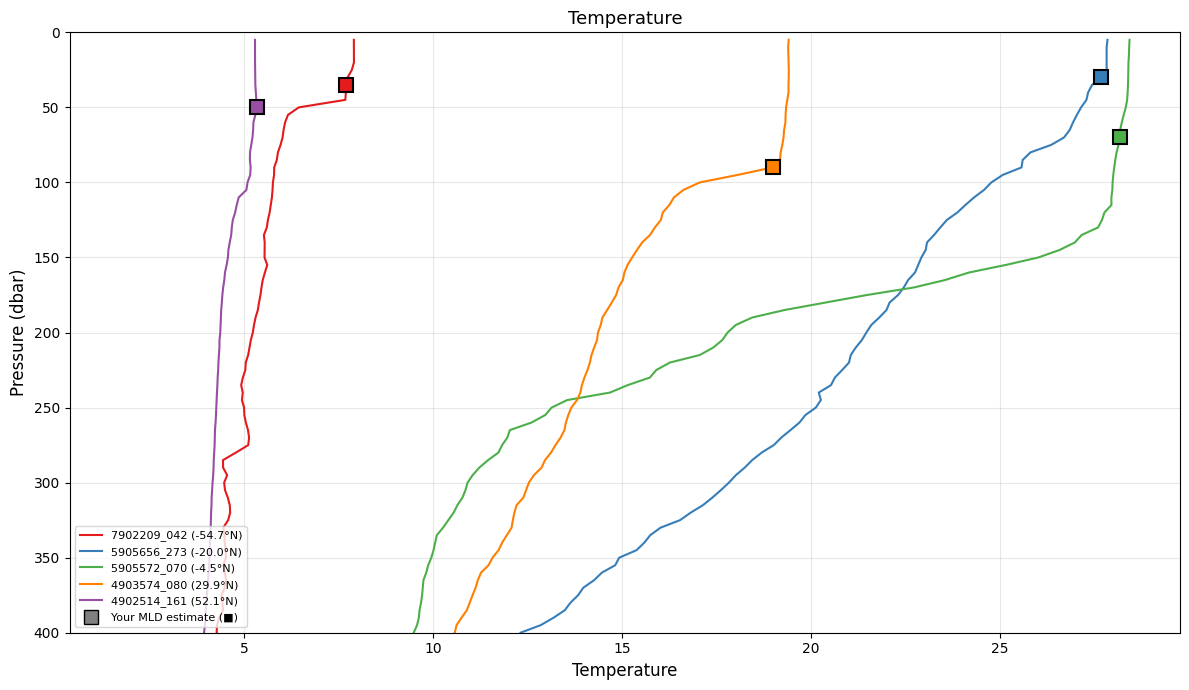

In [9]:
# ── Profiles with student MLD markers — run, do not modify ──────────────────────
plot_profiles_with_mld(platform_profiles, profiles_with_MLD_student,
                       varname='temperature', mld_key='MLD', colors=PROFILE_COLORS,
                       mld_marker='s')

### Step 5 — Helper estimates

The cell below computes several derived quantities automatically:
- **MLD** using threshold algorithms based on temperature and potential density
- **N²** (Brunt–Väisälä frequency squared) and the **oscillation period** at every depth, using `gsw.Nsquared`

**Why potential density?** The mixed layer is physically defined as the layer where water is well-mixed; this means it has uniform *density*, not just uniform temperature. In many regions this distinction is minor, because temperature dominates density variations near the surface. However, in some areas, particularly at high latitudes or near river outflows, salinity can vary sharply near the surface even when temperature is nearly uniform. In those cases, using temperature alone to define the MLD can be misleading: you might identify a deeper mixed layer than actually exists, or miss a thin stable layer created by fresher water sitting above saltier, denser water. Using potential density incorporates both temperature and salinity, giving a more physically complete picture of where the water column is truly well-mixed.

You do not need to modify this cell; run it as is.

In [10]:
# ── Compute derived properties (MLD, N², period) — run, do not modify ──────────
for ds, regions_list in platform_profiles.items():
    for region_list in regions_list:
        for time_list in region_list:
            for p in time_list:
                compute_derived_properties(p, temperature_key, salinity_key, ds)

print("✓ Computed MLD estimates, N², and oscillation period")

✓ Computed MLD estimates, N², and oscillation period


### Step 6 — Summary table
The table below collects all results: float ID, latitude, longitude, your estimated MLD and
ΔT, and the helper-calculated equivalents. This is the table you will present.

The **ML Salinity** column shows the mean salinity from the surface down to the
potential-density mixed layer depth (MLD Pot. Density), averaged over all interpolated
levels within that layer.

In [11]:
 # ── Compute ΔT from surface to MLD — run, do not modify ─────────────────────────
profiles_with_MLD_student = compute_dT_MLD_surf(profiles_with_MLD_student, platform_profiles)

In [12]:
# ── Summary table — run, do not modify ─────────────────────────────────────────
df_table = build_mld_summary_table(platform_profiles, profiles_with_MLD_student)


,Profile ID,Latitude,Longitude,MLD (m) Student,MLD (m) Temperature,ΔT (°C),MLD (m) Pot. Density,ML Salinity (psu)
0,7902209_042,-54.687000,-160.206000,35.000000,36.000000,-0.195000,45.500000,34.010000
1,5905656_273,-19.975000,-162.546000,30.000000,31.100000,-0.176000,27.300000,35.690000
2,5905572_070,-4.489000,-163.208000,70.000000,60.600000,-0.255000,51.600000,35.770000
3,4903574_080,29.913000,-169.760000,90.000000,80.400000,-0.424000,75.500000,34.940000
4,4902514_161,52.105000,-167.724000,50.000000,100.200000,0.045000,29.600000,32.320000



Compare your visual MLD estimates (Student) with the algorithmic estimates.
Since you estimated MLD from the temperature profile, the 'Temperature' column
is your most direct comparison. Differences with the potential-density-based estimates
reveal the role of salinity in setting the mixed-layer structure.

ML Salinity is the mean salinity over all interpolated levels from the surface
down to the potential-density mixed layer depth.


### Discussion: Why do we see differences in MLD across estimates?

Looking at the table above and the three-panel figure below, you may notice differences between the MLD estimates.

**Question 1:** Your visual estimate was based on temperature. How does it compare
with the algorithmic temperature-based estimate (★, ΔT = 0.2 °C)? If they differ,
why might that be?

**Question 2:** Now compare the temperature-based MLD (★) with the potential-density-based
MLD (●) in the figure. Are they at the same depth for every float? If not, what
physical property could cause the density structure to differ from the temperature
structure?

*Hint:* Look at the salinity panel. Where salinity changes sharply near the surface,
temperature alone may not capture the full picture of the mixed layer.

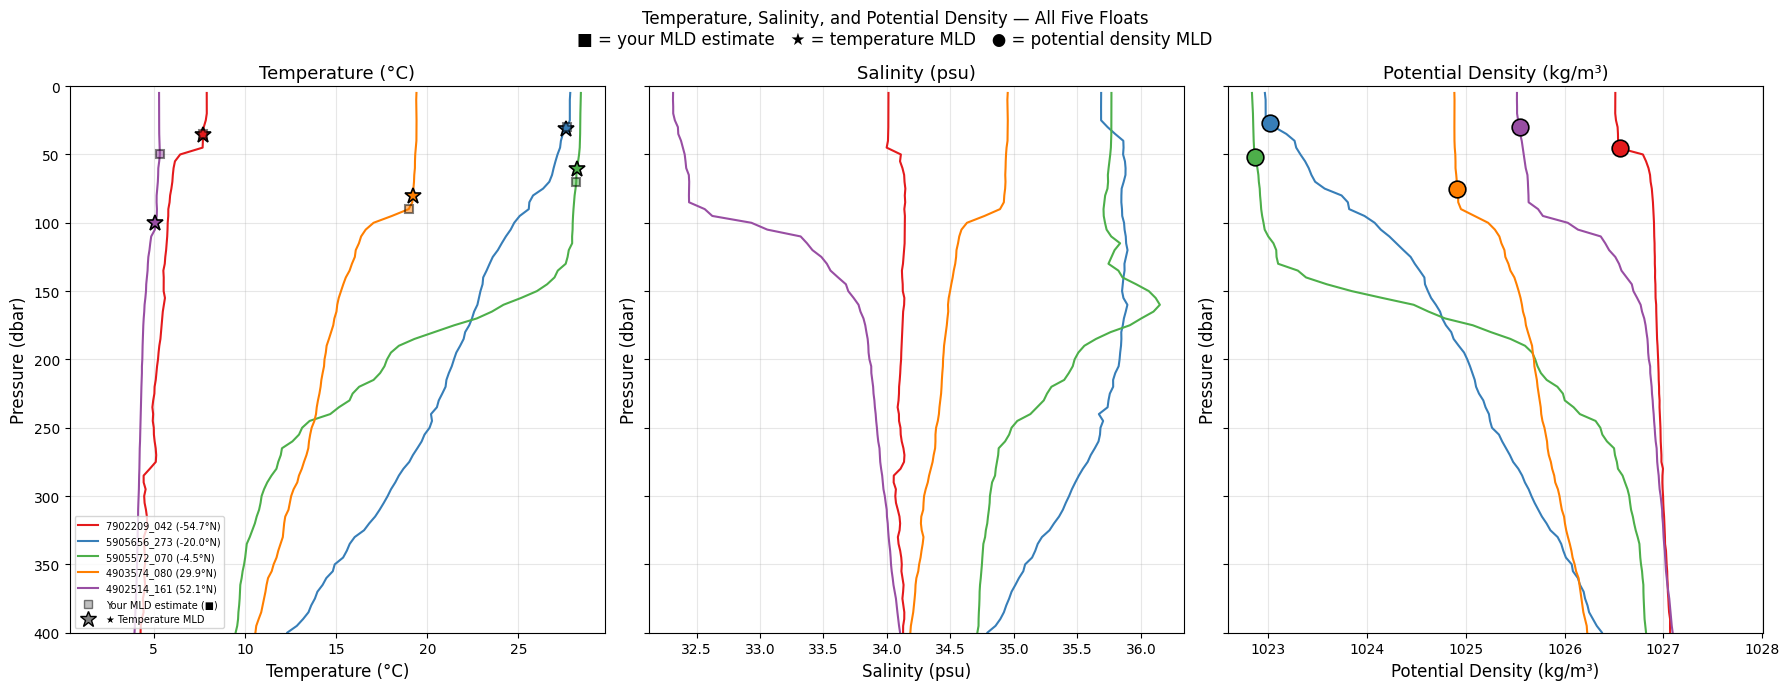

In [13]:
# ── Three-panel profiles with MLD markers — run, do not modify ─────────────────
fig, (ax_t, ax_s, ax_pd) = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

YLIM_MAX = 400

handles = plot_profiles_with_mld(
    platform_profiles, profiles_with_MLD_student,
    varname='temperature', mld_key='MLD', ylim_max=YLIM_MAX,
    title='Temperature (°C)', colors=PROFILE_COLORS, ax=ax_t,
    mld_marker='s', mld_markersize=6, mld_marker_alpha=0.5,
    helper_mld_key='MLD_temperature', helper_mld_marker='*')

plot_profiles_with_mld(
    platform_profiles, profiles_with_MLD_student,
    varname='salinity', mld_key=None, ylim_max=YLIM_MAX,
    title='Salinity (psu)', colors=PROFILE_COLORS, ax=ax_s)

plot_profiles_with_mld(
    platform_profiles, profiles_with_MLD_student,
    varname='potential_density', mld_key=None, ylim_max=YLIM_MAX,
    title='Potential Density (kg/m³)', colors=PROFILE_COLORS, ax=ax_pd,
    helper_mld_key='MLD_potdensity', helper_mld_marker='o')

ax_t.legend(handles=handles, fontsize=7, loc='lower left')
plt.suptitle('Temperature, Salinity, and Potential Density — All Five Floats\n'
             '■ = your MLD estimate   ★ = temperature MLD   ● = potential density MLD',
             fontsize=12)
plt.tight_layout()
plt.show()

### Step 7 — MLD vs. Latitude

The plot below shows **your** MLD estimates as a function of latitude. The helper estimate
is shown in the background for reference.

Look for patterns:
- Are mixed layers deeper in one hemisphere than the other?
- How does MLD vary between the tropics and higher latitudes?

**Extra credit:** What physical processes — such as wind forcing, solar radiation, and ocean
circulation — help explain the observed differences in MLD across latitudes?

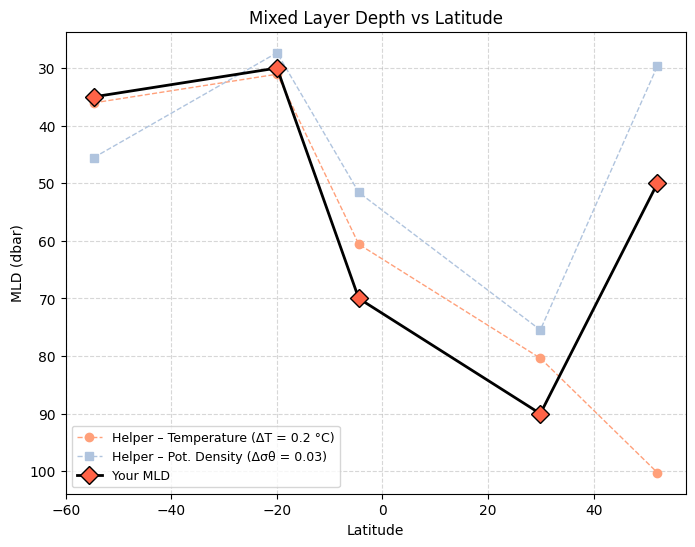

In [14]:
# ── MLD vs. latitude — run, do not modify ──────────────────────────────────────
plot_mld_vs_latitude(platform_profiles, profiles_with_MLD_student)

## Bridge Activity — Exploring Stratification and N² Across All Five Floats

Now that you have estimated the mixed layer depth from the temperature profiles, let's
look at the **vertical stratification** below the mixed layer.

Stratification describes how strongly the ocean density increases with depth. We measure
it using the **Brunt–Väisälä frequency squared (N²)**:

$$N^2 = -\frac{g}{\rho} \frac{\partial \rho}{\partial z}$$

where $g = 9.81$ m/s², $\rho$ is potential density, and $z$ is depth (negative downward).
When N² is large, the water column is strongly stratified — a displaced fluid parcel
oscillates rapidly back to its equilibrium depth. The **oscillation period** is:

$$T = \frac{2\pi}{\sqrt{N^2}} \quad \text{(seconds)}$$

In this section the helper computes everything automatically. Your job is to study the
three panels below and answer the discussion questions — no calculations required here.

### Step 1 — Potential density, N², and oscillation period for all five floats

The three rows of panels below show, for each float:
1. **Potential density** vs. depth — the steeper the gradient, the stronger the stratification
2. **N²** vs. depth — peaks mark the depth of maximum stratification
3. **Oscillation period** vs. depth — how long a displaced parcel takes to complete one cycle

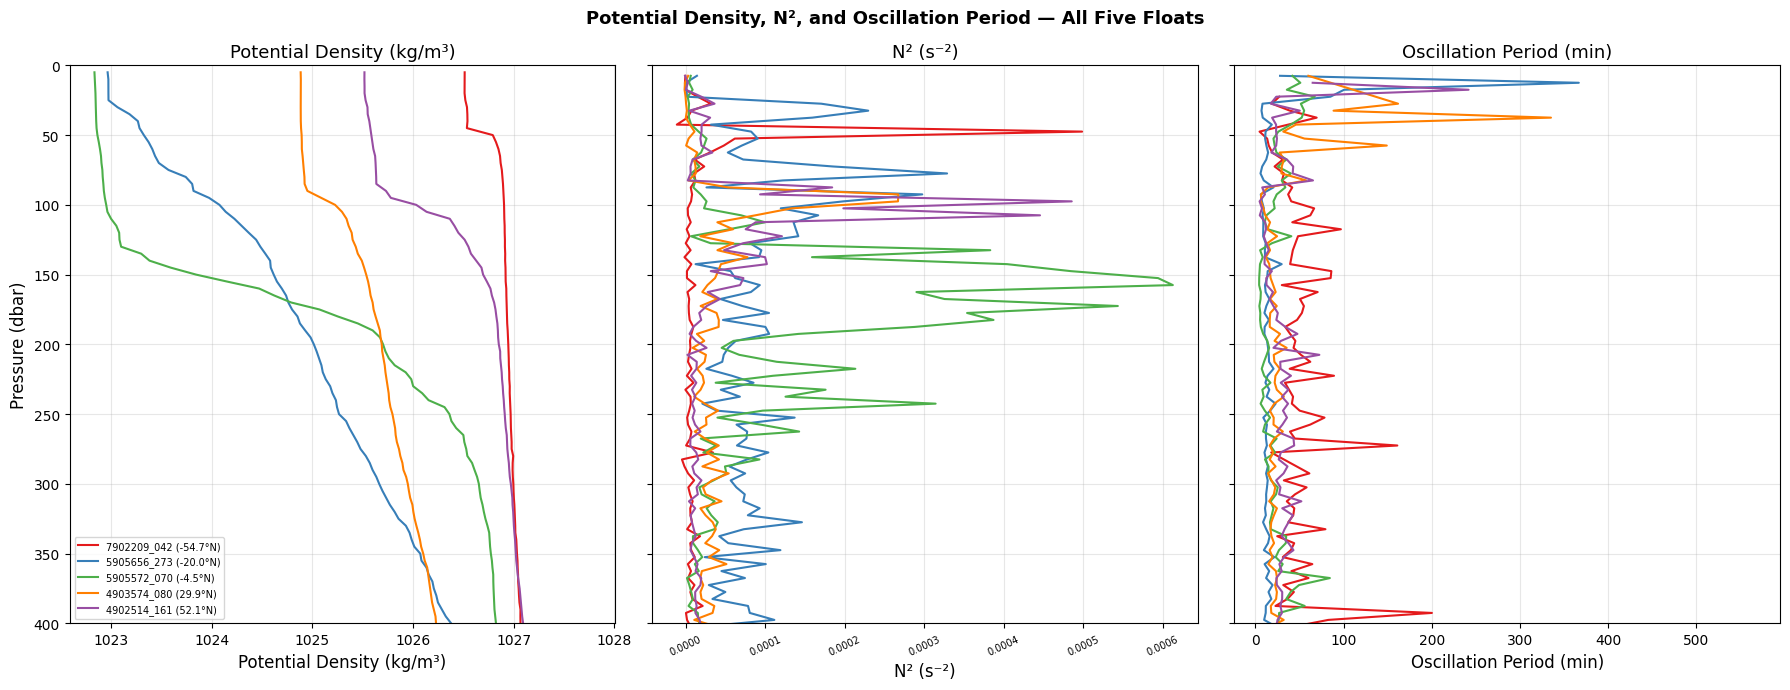

In [15]:
# ── N², potential density, and oscillation period — run, do not modify ──────────
all_profiles = [
    region_list[0][0]
    for ds, regions_list in platform_profiles.items()
    for region_list in regions_list
]

# Build a simple list of profile dicts for the function
bridge_profiles = [{'id': p.rawdata['_id']} for p in all_profiles]

YLIM_MAX_BRIDGE = 400

fig, (ax_pd, ax_n2, ax_T) = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# Potential density
handles = plot_profiles_with_mld(
    platform_profiles, bridge_profiles,
    varname='potential_density', mld_key=None, ylim_max=YLIM_MAX_BRIDGE,
    title='Potential Density (kg/m³)', colors=PROFILE_COLORS, ax=ax_pd)

# N² (uses mid-point pressure grid)
plot_profiles_with_mld(
    platform_profiles, bridge_profiles,
    varname='N2', mld_key=None, ylim_max=YLIM_MAX_BRIDGE,
    title='N² (s⁻²)', colors=PROFILE_COLORS, ax=ax_n2,
    pressure_key='N2_pressure')

# Oscillation period (same mid-point grid as N²)
plot_profiles_with_mld(
    platform_profiles, bridge_profiles,
    varname='oscillation_period', mld_key=None, ylim_max=YLIM_MAX_BRIDGE,
    title='Oscillation Period (min)', colors=PROFILE_COLORS, ax=ax_T,
    pressure_key='N2_pressure')

ax_n2.set_ylabel('')
ax_T.set_ylabel('')
ax_n2.tick_params(axis='x', labelsize=7, rotation=25)

ax_pd.legend(handles=handles, fontsize=7, loc='lower left')
plt.suptitle('Potential Density, N², and Oscillation Period — All Five Floats',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Bridge Activity — Discussion questions

Study the three panels above and answer the following questions.

✏️ **Student Work — Q1: N² shape vs. latitude**

**Q1.** How does the shape of the N² profile change with latitude? Where is stratification concentrated — near the surface, at mid-depth, or spread over a wide range?

*Double-click to edit this cell and write your answer.*

✏️ **Student Work — Q2: Maximum N² vs. latitude**

**Q2.** How does the maximum value of N² change with latitude? Which float has the strongest peak stratification?

*Double-click to edit this cell and write your answer.*

✏️ **Student Work — Q3: Oscillation period vs. latitude**

**Q3.** How does the oscillation period profile change with latitude? At the depth of maximum N², what is the approximate period for each float?

*Double-click to edit this cell and write your answer.*

✏️ **Student Work — Q4: Minimum oscillation period**

**Q4.** How does the minimum oscillation period (corresponding to the N² peak) change with latitude?

*Double-click to edit this cell and write your answer.*

✏️ **Student Work — Q5: Physical drivers (extra credit)**

**Q5.** What physical processes — such as wind forcing, solar radiation, and ocean circulation — help explain the observed changes in the vertical N² profile across latitudes?

*Double-click to edit this cell and write your answer.*

## Activity 2 — Vertical Stratification (N²) vs. Depth and Ocean Basin

Now you will **calculate N² by hand** at two depths for two floats from different ocean
basins at roughly the same latitude, and compare the results.

The Brunt–Väisälä frequency squared is:

$$N^2 = -\frac{g}{\rho} \frac{\Delta\rho}{\Delta z}$$

where $g = 9.81$ m/s², $\rho$ is potential density at the target depth, and
$\Delta\rho / \Delta z$ is the density gradient estimated from the levels immediately
above and below.

### Step 1 — Select your first float and inspect its profile

Choose one of your five Activity 1 floats. The cell below plots its temperature,
salinity, and potential density profiles. Use the density profile to identify
where stratification is strongest (steepest gradient).

✏️ **Student Work — Float Selection (Activity 2)**

Choose one of your five Activity 1 floats to analyse in detail. Change the index below: `[0][0][0]` selects float 0, `[1][0][0]` selects float 1, and so on (valid range: 0–4).

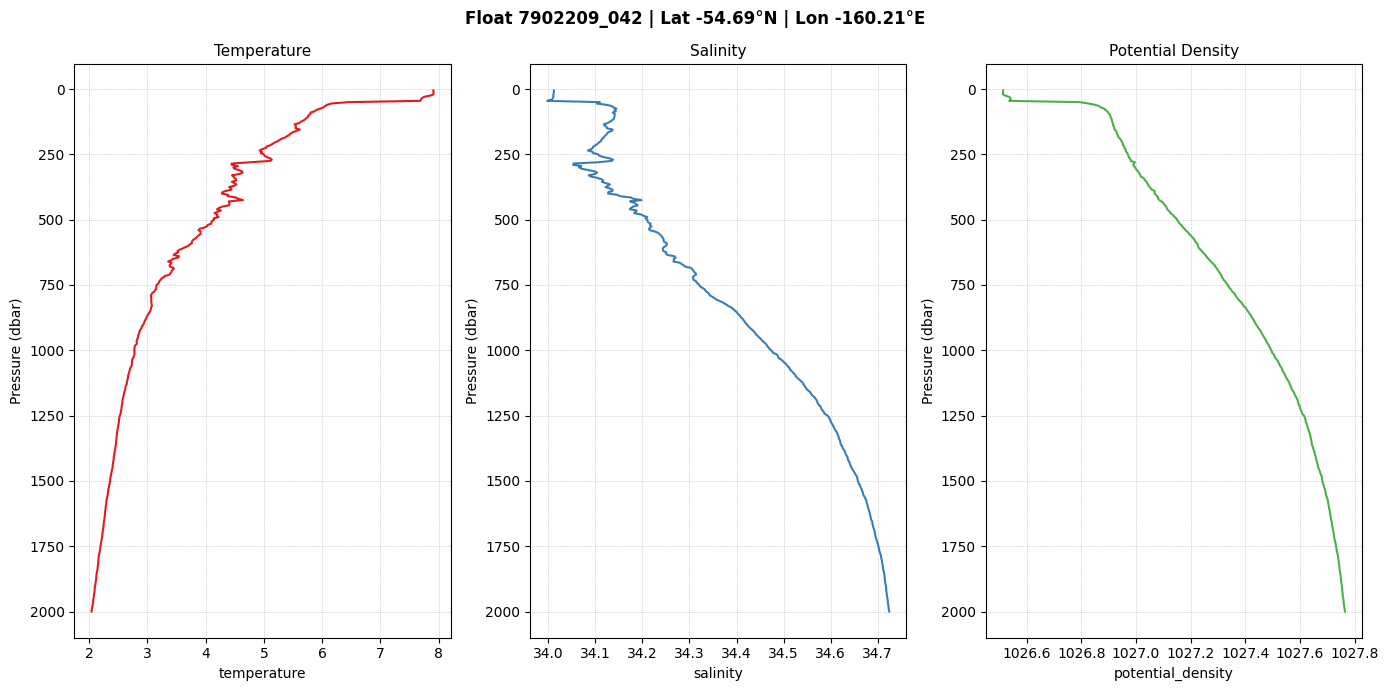

In [16]:
# MODIFY HERE — change the index [0][0][0] to select your float (0–4)
# Select one of your Activity 1 floats by index (0–4)
selected_float = platform_profiles['argo'][0][0][0]

# Plot temperature, salinity, and potential density profiles
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 7))

# Temperature
compare_profiles(
    {'argo': [selected_float]},
    varname='temperature',
    dataset_colors={'argo': '#e41a1c'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax1,
)
ax1.set_title('Temperature', fontsize=11)

# Salinity
compare_profiles(
    {'argo': [selected_float]},
    varname='salinity',
    dataset_colors={'argo': '#377eb8'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax2,
)
ax2.set_title('Salinity', fontsize=11)

# Potential Density
compare_profiles(
    {'argo': [selected_float]},
    varname='potential_density',
    dataset_colors={'argo': '#4daf4a'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax3,
)
ax3.set_title('Potential Density', fontsize=11)

plt.suptitle(f"Float {selected_float.rawdata['_id']} | "
             f"Lat {selected_float.latitude:.2f}°N | "
             f"Lon {selected_float.longitude:.2f}°E",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 2 — Choose your two target depths

✏️ **Student Work — Choose Target Depths**

From the density profile above, identify two depths of interest:

- **Depth 1:** where the density gradient is steepest (strongest stratification)
- **Depth 2:** a second depth of your choice (e.g. ~1000 dbar as a deep reference)

Uncomment the template lines and replace `None` with your chosen depths in dbar.

In [17]:
# MODIFY HERE
depth_1 = 100
depth_2 = 1000
# Enter your two target depths (in dbar):
# depth_1 = None
# depth_2 = None

### Step 3 — Read T and S at your two depths

✏️ **Student Work — Potential Density Values**

Use the T and S values printed above to compute potential density manually (e.g. with an online seawater calculator at reference pressure p = 0 dbar).

Uncomment the `rho_1` and `rho_2` lines at the top of the cell below and fill in your values (kg/m³).

In [18]:
# MODIFY HERE
# --- STUDENT WORK: after reading T and S below, fill in your potential density values above ---
# rho_1 = None   # ← potential density at depth_1 (kg/m³)
# rho_2 = None   # ← potential density at depth_2 (kg/m³)

# ── Read T and S at your chosen depths from the profile ──────────────────────────────────────
pressure_arr = _arr(selected_float.getvar('pressure'))
temp_arr     = _arr(selected_float.getvar('temperature'))
sal_arr      = _arr(selected_float.getvar('salinity'))

# Find the index closest to each target depth
idx_1 = np.argmin(np.abs(pressure_arr - depth_1))
idx_2 = np.argmin(np.abs(pressure_arr - depth_2))

print(f"Depth 1 ({pressure_arr[idx_1]:.1f} dbar):")
print(f"  T = {temp_arr[idx_1]:.4f}°C")
print(f"  S = {sal_arr[idx_1]:.4f} psu")
print()
print(f"Depth 2 ({pressure_arr[idx_2]:.1f} dbar):")
print(f"  T = {temp_arr[idx_2]:.4f}°C")
print(f"  S = {sal_arr[idx_2]:.4f} psu")
print()
print("Use a calculator (or gsw functions) with T and S above to compute")
print("potential density (σθ) at each depth, then fill in the values above.")

Depth 1 (100.0 dbar):
  T = 5.7670°C
  S = 34.1408 psu

Depth 2 (1000.0 dbar):
  T = 2.7790°C
  S = 34.4732 psu

Use a calculator (or gsw functions) with T and S above to compute
potential density (σθ) at each depth, then fill in the values above.


### Step 4 — Calculate N² at both depths

✏️ **Student Work — Calculate N² and Oscillation Period (Float 1)**

**Run this cell once first** to print the neighboring pressure levels around your two target depths. Use those values together with your potential density estimates to compute N² at each depth using the central-difference formula:

$$N^2 = -\frac{g}{\rho} \frac{\rho_{\text{above}} - \rho_{\text{below}}}{z_{\text{above}} - z_{\text{below}}}$$

Then compute the oscillation period: $T = 2\pi / \sqrt{N^2} \div 60$ (minutes). Uncomment and fill in the `# --- STUDENT WORK ---` block at the bottom of the cell and run it again to enter your results.

In [19]:
# MODIFY HERE
g = 9.81

pressure_arr = _arr(selected_float.getvar('pressure'))
idx_1 = np.argmin(np.abs(pressure_arr - depth_1))
idx_2 = np.argmin(np.abs(pressure_arr - depth_2))

# --- Depth 1 ---
print(f"Depth 1 ({pressure_arr[idx_1]:.0f} dbar):")
print(f"  one step above: {pressure_arr[idx_1-1]:.0f} dbar")
print(f"  one step below: {pressure_arr[idx_1+1]:.0f} dbar")
print()
print(f"Depth 2 ({pressure_arr[idx_2]:.0f} dbar):")
print(f"  one step above: {pressure_arr[idx_2-1]:.0f} dbar")
print(f"  one step below: {pressure_arr[idx_2+1]:.0f} dbar")
print()
print("Using the formula  N² = -(g/ρ) × (Δρ/Δz),  compute N² at each depth by hand")
print("or with a calculator, then enter your results below.")

# --- STUDENT WORK: fill in your density values and your computed N² ---
# rho_1      = None  # ρ at depth_1
# rho_up_1   = None  # ρ one step above depth_1
# rho_down_1 = None  # ρ one step below depth_1

# rho_2      = None  # ρ at depth_2
# rho_up_2   = None  # ρ one step above depth_2
# rho_down_2 = None  # ρ one step below depth_2

# N2_1 = None        # ← your computed N² at depth_1 (s⁻²)
# N2_2 = None        # ← your computed N² at depth_2 (s⁻²)

# T_1  = None        # ← your computed oscillation period at depth_1 (min)
# T_2  = None        # ← your computed oscillation period at depth_2 (min)

# --- Instructor reference: formula for checking (leave commented in student version) ---
# dz_1 = -(pressure_arr[idx_1-1] - pressure_arr[idx_1+1])
# N2_1 = -(g / rho_1) * ((rho_up_1 - rho_down_1) / dz_1)
# T_1  = (2*np.pi / np.sqrt(N2_1)) / 60

# dz_2 = -(pressure_arr[idx_2-1] - pressure_arr[idx_2+1])
# N2_2 = -(g / rho_2) * ((rho_up_2 - rho_down_2) / dz_2)
# T_2  = (2*np.pi / np.sqrt(N2_2)) / 60

Depth 1 (100 dbar):
  one step above: 95 dbar
  one step below: 105 dbar

Depth 2 (1000 dbar):
  one step above: 995 dbar
  one step below: 1005 dbar

Using the formula  N² = -(g/ρ) × (Δρ/Δz),  compute N² at each depth by hand
or with a calculator, then enter your results below.


### Step 5 — Find a float in the other ocean basin

✏️ **Student Work — Second Float ID**

Go to [argovis.colorado.edu/argo](https://argovis.colorado.edu/argo) and find a float at roughly the **same latitude** as your selected float, but in the **other ocean basin** (Atlantic ↔ Pacific).

Uncomment the `second_float_id` line below and replace `"???"` with the profile ID you found.

In [20]:
# MODIFY HERE
second_float_id = "1902725_054"
# Enter your second float ID (other ocean basin, same latitude):
# second_float_id = "???"

second_results = traverse_query(
    [{"id": second_float_id}], time_periods, argo_collections,
    avh.queryProfile,
    apikey=APIKEY, apiroot=APIROOT)

second_profiles = {}
for ds, route_results in second_results.items():
    second_profiles[ds] = []
    for region_results in route_results:
        region_list = []
        for time_results in region_results:
            time_out = []
            for p in time_results:
                try:
                    time_out.append(ava.interpolate_all(p, interpolation_levels))
                except ValueError:
                    pass
            region_list.append(time_out)
        second_profiles[ds].append(region_list)

selected_float_2 = second_profiles['argo'][0][0][0]
compute_derived_properties(selected_float_2, temperature_key, salinity_key, 'argo')

print(f"Float 2: {selected_float_2.rawdata['_id']} | "
      f"Lat {selected_float_2.latitude:.2f}°N, "
      f"Lon {selected_float_2.longitude:.2f}°E")

Float 2: 1902725_054 | Lat -53.64°N, Lon -23.89°E


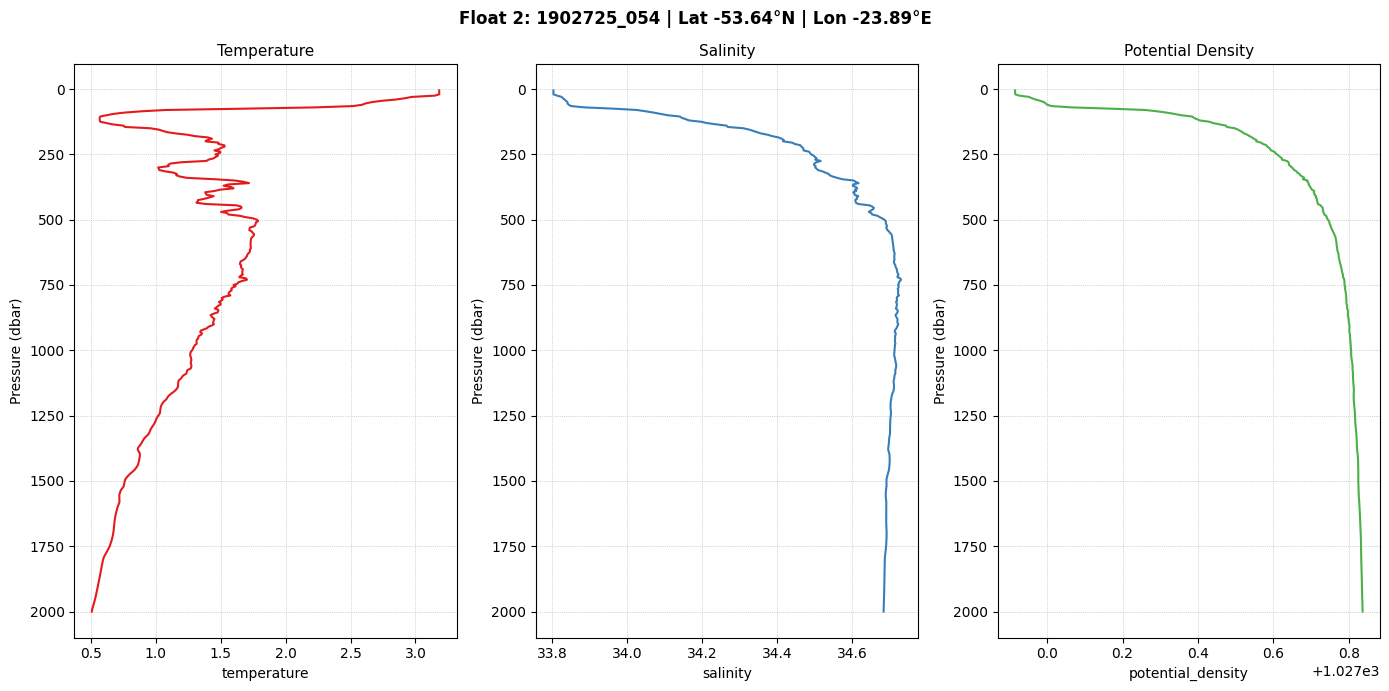

In [21]:
# ── Float 2 profiles — run, do not modify ───────────────────────────────────────
# Plot temperature, salinity, and potential density profiles for Float 2
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 7))

compare_profiles(
    {'argo': [selected_float_2]},
    varname='temperature',
    dataset_colors={'argo': '#e41a1c'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax1,
)
ax1.set_title('Temperature', fontsize=11)

compare_profiles(
    {'argo': [selected_float_2]},
    varname='salinity',
    dataset_colors={'argo': '#377eb8'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax2,
)
ax2.set_title('Salinity', fontsize=11)

compare_profiles(
    {'argo': [selected_float_2]},
    varname='potential_density',
    dataset_colors={'argo': '#4daf4a'},
    time_linestyles=['-'],
    mean_style=True,
    ax=ax3,
)
ax3.set_title('Potential Density', fontsize=11)

plt.suptitle(f"Float 2: {selected_float_2.rawdata['_id']} | "
             f"Lat {selected_float_2.latitude:.2f}°N | "
             f"Lon {selected_float_2.longitude:.2f}°E",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

✏️ **Student Work — N² and Period for Float 2**

**Run this cell once first** to print T and S at your two target depths for Float 2, along with the neighboring pressure levels needed for the central-difference formula. Then repeat the same N² calculation you did for Float 1 in Step 4 — uncomment and fill in the `# --- STUDENT WORK ---` block at the bottom of the cell and run it again to enter your results.

In [22]:
# MODIFY HERE
# Read T and S at the same two depths for Float 2
pressure_arr_2 = _arr(selected_float_2.getvar('pressure'))
temp_arr_2     = _arr(selected_float_2.getvar('temperature'))
sal_arr_2      = _arr(selected_float_2.getvar('salinity'))

idx_1_f2 = np.argmin(np.abs(pressure_arr_2 - depth_1))
idx_2_f2 = np.argmin(np.abs(pressure_arr_2 - depth_2))

print(f"Depth 1 ({pressure_arr_2[idx_1_f2]:.1f} dbar):")
print(f"  T = {temp_arr_2[idx_1_f2]:.4f}°C")
print(f"  S = {sal_arr_2[idx_1_f2]:.4f} psu")
print(f"  one step above: {pressure_arr_2[idx_1_f2-1]:.0f} dbar")
print(f"  one step below: {pressure_arr_2[idx_1_f2+1]:.0f} dbar")
print()
print(f"Depth 2 ({pressure_arr_2[idx_2_f2]:.1f} dbar):")
print(f"  T = {temp_arr_2[idx_2_f2]:.4f}°C")
print(f"  S = {sal_arr_2[idx_2_f2]:.4f} psu")
print(f"  one step above: {pressure_arr_2[idx_2_f2-1]:.0f} dbar")
print(f"  one step below: {pressure_arr_2[idx_2_f2+1]:.0f} dbar")
print()
print("Using the formula  N² = -(g/ρ) × (Δρ/Δz),  compute N² at each depth by hand")
print("or with a calculator, then enter your results below.")

# --- STUDENT WORK: fill in your density values and your computed N² ---
# rho_1_f2      = None  # ρ at depth_1
# rho_up_1_f2   = None  # ρ one step above depth_1
# rho_down_1_f2 = None  # ρ one step below depth_1

# rho_2_f2      = None  # ρ at depth_2
# rho_up_2_f2   = None  # ρ one step above depth_2
# rho_down_2_f2 = None  # ρ one step below depth_2

# N2_1_f2 = None        # ← your computed N² at depth_1 (s⁻²)
# N2_2_f2 = None        # ← your computed N² at depth_2 (s⁻²)

# T_1_f2  = None        # ← your computed oscillation period at depth_1 (min)
# T_2_f2  = None        # ← your computed oscillation period at depth_2 (min)

Depth 1 (100.0 dbar):
  T = 0.6199°C
  S = 34.1077 psu
  one step above: 95 dbar
  one step below: 105 dbar

Depth 2 (1000.0 dbar):
  T = 1.2790°C
  S = 34.7128 psu
  one step above: 995 dbar
  one step below: 1005 dbar

Using the formula  N² = -(g/ρ) × (Δρ/Δz),  compute N² at each depth by hand
or with a calculator, then enter your results below.


### Step 7 — Summary table

✏️ **Student Work — Summary Table**

Once you have completed Steps 4, 6 and entered your periods in the cell above:

1. **Uncomment** all lines below (`Ctrl+/` or `Cmd+/`)
2. **Replace** each `None` with the corresponding variable (`N2_1`, `N2_2`, `N2_1_f2`, `N2_2_f2`) and your calculated period variables (`T_1`, `T_2`, `T_1_f2`, `T_2_f2`)

In [23]:
# MODIFY HERE
# --- STUDENT WORK: uncomment and fill in after completing Steps 4 and 6 ---
# results = [
#     {"Float": selected_float.rawdata['_id'],
#      "Basin": "Float 1",
#      "Lat":   round(selected_float.latitude, 2),
#      "Depth (dbar)": depth_1,
#      "N² (s⁻²)":    f"{N2_1:.2e}",
#      "Period (min)": f"{T_1:.1f}"},   # ← enter your calculated period
#     {"Float": selected_float.rawdata['_id'],
#      "Basin": "Float 1",
#      "Lat":   round(selected_float.latitude, 2),
#      "Depth (dbar)": depth_2,
#      "N² (s⁻²)":    f"{N2_2:.2e}",
#      "Period (min)": f"{T_2:.1f}"},   # ← enter your calculated period
#     {"Float": selected_float_2.rawdata['_id'],
#      "Basin": "Float 2",
#      "Lat":   round(selected_float_2.latitude, 2),
#      "Depth (dbar)": depth_1,
#      "N² (s⁻²)":    f"{N2_1_f2:.2e}",
#      "Period (min)": f"{T_1_f2:.1f}"},   # ← enter your calculated period
#     {"Float": selected_float_2.rawdata['_id'],
#      "Basin": "Float 2",
#      "Lat":   round(selected_float_2.latitude, 2),
#      "Depth (dbar)": depth_2,
#      "N² (s⁻²)":    f"{N2_2_f2:.2e}",
#      "Period (min)": f"{T_2_f2:.1f}"},   # ← enter your calculated period
# ]
# display(pd.DataFrame(results))

### Reflection — Comparing two ocean basins

**Questions for reflection:**

1. How do the N² values compare between Float 1 and Float 2 at the same depths?
2. Are the oscillation periods similar or different? What might explain the differences?
3. What role might differences in temperature and salinity (T/S) structure play?

Consider that the Brunt–Väisälä frequency depends on density gradients, which in turn
depend on both temperature and salinity changes. Even if two floats are at similar
latitudes, their T/S properties can differ due to different water mass origins and
mixing histories.

*Double-click to edit this cell and write your answer.*